# A3 Offset — controlling when handovers happen

**A3 condition** (per UE, per tick, sustained for TTT):

```
RSRP(target_gNB) > RSRP(serving_gNB) + A3_offset + hysteresis
```

| Offset | Effect | HO boundary |
|:------:|:------:|:-----------:|
| negative (−6 dB) | target looks *stronger* → HO earlier | before midpoint |
| 0 dB | natural boundary | near midpoint |
| positive (+6 dB) | target needs to be *stronger* → HO later | past midpoint |

**Demo**: 5 eMBB UEs move from gNB-0 toward gNB-1.  
We compare three fixed offset values on the gNB-0 → gNB-1 link and observe how the load shifts.

In [1]:
import os, sys
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-chech')
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scenario_creator import create_multignb_env

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Ready')

Ready


## Configuration

In [2]:
TICK_S       = 0.001
SIM_S        = 50.0
N_TICKS      = int(SIM_S / TICK_S)
TTT_S        = 0.5          # time-to-trigger: A3 must be satisfied for this long
TTT_TICKS    = int(TTT_S / TICK_S)
HYSTERESIS   = 1.0          # dB — prevents ping-pong at the boundary

# A3 offsets to compare (gNB-0 → gNB-1 link)
OFFSETS_DB   = [-6.0, 0.0, 6.0]
OFFSET_LABELS = {-6.0: '−6 dB  (early HO)',
                  0.0: ' 0 dB  (natural)',
                  6.0: '+6 dB  (late HO)'}

# 5 UEs start near gNB-0, move at vx=8 m/s toward gNB-1
# Starting positions staggered so HOs spread over time
UE_STARTS_X = [10, 30, 50, 70, 90]   # metres from gNB-0
VX          = 8.0                      # m/s

GNB_CONFIGS = [
    {'id': 0, 'x':   0.0, 'y': 0.0, 'coverage_radius': 520.0, 'carrier_id': 0, 'n_prbs': 100},
    {'id': 1, 'x': 450.0, 'y': 0.0, 'coverage_radius': 520.0, 'carrier_id': 1, 'n_prbs': 100},
    {'id': 2, 'x': 225.0, 'y': 390.0, 'coverage_radius': 520.0, 'carrier_id': 2, 'n_prbs': 100},
]

print(f'Simulation: {SIM_S:.0f} s  ({N_TICKS} ticks at {TICK_S*1000:.0f} ms/tick)')
print(f'TTT: {TTT_S*1000:.0f} ms  |  hysteresis: {HYSTERESIS} dB')
print(f'UE speed: {VX} m/s  →  crosses midpoint (225 m) in {(225-50)/VX:.0f}–{(225-10)/VX:.0f} s')

Simulation: 50 s  (50000 ticks at 1 ms/tick)
TTT: 500 ms  |  hysteresis: 1.0 dB
UE speed: 8.0 m/s  →  crosses midpoint (225 m) in 22–27 s


## Run one simulation per offset value

In [3]:
SAMPLE_EVERY = 10   # record every 10 ms

results = {}   # offset_db → {'df': DataFrame, 'ho_events': list}

for offset_db in OFFSETS_DB:
    env = create_multignb_env(
        rng=np.random.default_rng(0),
        n=4,
        slots_per_step=1,
        L1_level=False,
        gnb_configs=GNB_CONFIGS,
        step_dt=TICK_S,
        mobility_dt=TICK_S,
        radio_substeps=1,
        max_episode_steps=N_TICKS + 1,
        max_prbs_per_ue=None,
        handover_ttt=TTT_TICKS,
        a3_handover_cooldown_s=5.0,
        a3_min_residence_s=2.0,
        max_handovers_per_ue_episode=1,   # each UE HOs at most once
    )
    env.a3_hysteresis_db = HYSTERESIS

    # Set the offset on gNB-0 → gNB-1 for all slice types
    for sl in ('eMBB', 'URLLC', 'mMTC'):
        env.set_a3_offset(0, 1, sl, float(offset_db))

    # Add 5 UEs moving toward gNB-1
    for x0 in UE_STARTS_X:
        env.add_ue(
            x=float(x0), y=0., vx=VX, vy=0.,
            slice_type='eMBB',
            bit_rate=12e6,
            packet_size_bits=12_000.,
            traffic_model='fixed_packet_cbr',
        )

    all_ues  = env.get_all_ues()
    prev_gnb = {u.id: int(u.serving_gnb) for u in all_ues}
    records  = []
    ho_events = []

    for tick in range(N_TICKS):
        env.step(0)

        # detect handover events
        for u in all_ues:
            sg = int(u.serving_gnb) if u.serving_gnb is not None else -1
            if sg != prev_gnb[u.id]:
                ho_events.append({'time_s': tick * TICK_S,
                                  'ue_id': u.id,
                                  'from_gnb': prev_gnb[u.id],
                                  'to_gnb': sg,
                                  'x': round(float(u.x), 1)})
                prev_gnb[u.id] = sg

        if tick % SAMPLE_EVERY == 0:
            loads = env.get_slice_loads()
            records.append({
                'time_s': (tick + 1) * TICK_S,
                'g0_eMBB': float(loads.get((0, 'eMBB'), 0.0)),
                'g1_eMBB': float(loads.get((1, 'eMBB'), 0.0)),
                'n_g0': sum(1 for u in all_ues if u.connected and int(u.serving_gnb) == 0),
                'n_g1': sum(1 for u in all_ues if u.connected and int(u.serving_gnb) == 1),
            })

    env.close()
    results[offset_db] = {'df': pd.DataFrame(records), 'ho_events': ho_events}
    n_ho = len(ho_events)
    print(f'offset={offset_db:+5.1f} dB  →  {n_ho} HOs  |  '
          + ('  '.join(f"UE-{e['ue_id']} at t={e['time_s']:.1f}s x={e['x']:.0f}m" for e in ho_events[:5])))

offset= -6.0 dB  →  5 HOs  |  UE-4 at t=13.1s x=195m  UE-3 at t=15.6s x=195m  UE-2 at t=18.1s x=195m  UE-1 at t=20.6s x=195m  UE-0 at t=23.1s x=195m
offset= +0.0 dB  →  5 HOs  |  UE-4 at t=18.2s x=236m  UE-3 at t=20.7s x=236m  UE-2 at t=23.2s x=236m  UE-1 at t=25.7s x=236m  UE-0 at t=28.2s x=236m
offset= +6.0 dB  →  5 HOs  |  UE-4 at t=23.3s x=276m  UE-3 at t=25.8s x=276m  UE-2 at t=28.3s x=276m  UE-1 at t=30.8s x=276m  UE-0 at t=33.3s x=276m


## Load over time — three offsets compared

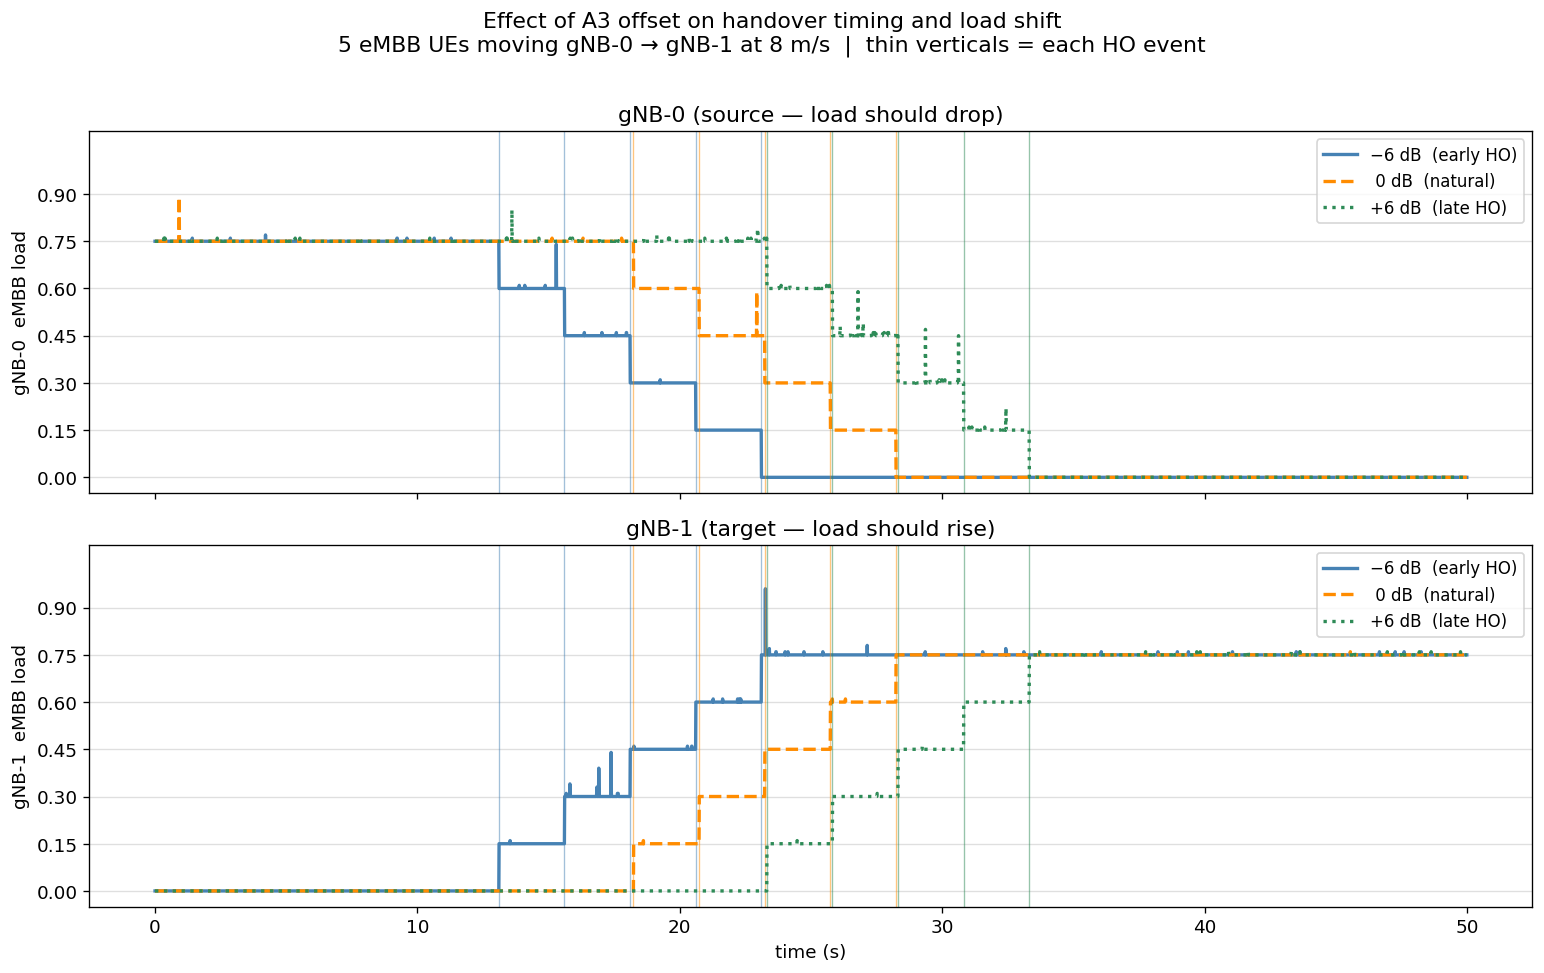

In [4]:
colors  = {-6.0: 'steelblue', 0.0: 'darkorange', 6.0: 'seagreen'}
styles  = {-6.0: '-',          0.0: '--',           6.0: ':'}

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
ax_g0, ax_g1 = axes

for offset_db, res in results.items():
    df    = res['df']
    color = colors[offset_db]
    ls    = styles[offset_db]
    label = OFFSET_LABELS[offset_db]
    ax_g0.plot(df['time_s'], df['g0_eMBB'], color=color, ls=ls, lw=2.0, label=label)
    ax_g1.plot(df['time_s'], df['g1_eMBB'], color=color, ls=ls, lw=2.0, label=label)
    # Mark HO times as vertical lines
    for ev in res['ho_events']:
        ax_g0.axvline(ev['time_s'], color=color, lw=0.8, alpha=0.5)
        ax_g1.axvline(ev['time_s'], color=color, lw=0.8, alpha=0.5)

ax_g0.set_ylabel('gNB-0  eMBB load')
ax_g1.set_ylabel('gNB-1  eMBB load')
ax_g1.set_xlabel('time (s)')

for ax, title in zip(axes, ['gNB-0 (source — load should drop)',
                              'gNB-1 (target — load should rise)']):
    ax.set_ylim(-0.05, 1.10)
    ax.set_yticks([i * 0.15 for i in range(7)])
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(axis='y', alpha=0.4)
    ax.set_title(title)

plt.suptitle('Effect of A3 offset on handover timing and load shift\n'
             '5 eMBB UEs moving gNB-0 → gNB-1 at 8 m/s  |  thin verticals = each HO event',
             y=1.01)
plt.tight_layout()
plt.show()

## HO position — where each UE switches cells

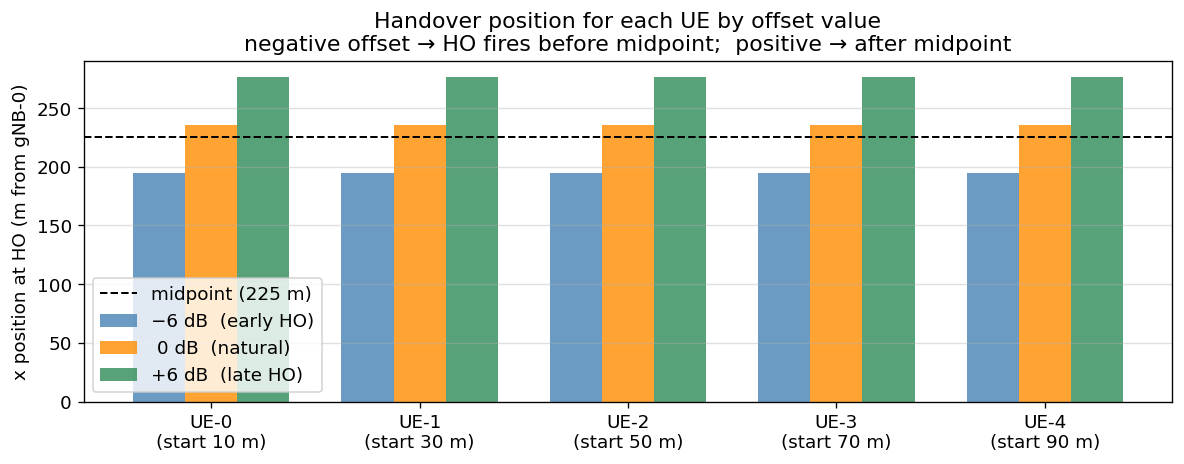

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))

bar_width = 0.25
x_pos     = np.arange(len(UE_STARTS_X))

for i, (offset_db, res) in enumerate(sorted(results.items())):
    ho_xs = []
    for ev in sorted(res['ho_events'], key=lambda e: e['ue_id']):
        ho_xs.append(ev['x'])
    while len(ho_xs) < len(UE_STARTS_X):
        ho_xs.append(float('nan'))
    offset_x = (i - 1) * bar_width
    bars = ax.bar(x_pos + offset_x, ho_xs, bar_width,
                  color=colors[offset_db], alpha=0.8, label=OFFSET_LABELS[offset_db])

ax.axhline(225, color='k', linestyle='--', lw=1.2, label='midpoint (225 m)')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'UE-{i}\n(start {x0} m)' for i, x0 in enumerate(UE_STARTS_X)])
ax.set_ylabel('x position at HO (m from gNB-0)')
ax.set_title('Handover position for each UE by offset value\n'
             'negative offset → HO fires before midpoint;  positive → after midpoint')
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

## Summary table — HO timing and final load

In [6]:
print('HO events per offset:')
print(f'{"offset":>8}  {"UE":>4}  {"HO time (s)":>12}  {"HO position (m)":>16}')
print('-' * 46)
for offset_db, res in sorted(results.items()):
    for ev in sorted(res['ho_events'], key=lambda e: e['ue_id']):
        print(f"{offset_db:>+8.1f}  UE-{ev['ue_id']}  {ev['time_s']:>12.2f}  {ev['x']:>16.1f}")
    if not res['ho_events']:
        print(f"{offset_db:>+8.1f}  (no HOs completed)")
    print()

print('Final load (last 2 s average):')
print(f'{"offset":>8}  {"gNB-0 load":>11}  {"gNB-1 load":>11}  {"load shift":>10}')
print('-' * 46)
for offset_db, res in sorted(results.items()):
    df   = res['df']
    tail = df[df['time_s'] >= SIM_S - 2.0]
    g0   = tail['g0_eMBB'].mean()
    g1   = tail['g1_eMBB'].mean()
    shift = g0 - 0.75   # how much load left gNB-0 vs initial
    print(f"{offset_db:>+8.1f}  {g0:>11.3f}  {g1:>11.3f}  {shift:>+10.3f}")

HO events per offset:
  offset    UE   HO time (s)   HO position (m)
----------------------------------------------
    -6.0  UE-0         23.10             194.8
    -6.0  UE-1         20.60             194.8
    -6.0  UE-2         18.10             194.8
    -6.0  UE-3         15.60             194.8
    -6.0  UE-4         13.10             194.8

    +0.0  UE-0         28.23             235.9
    +0.0  UE-1         25.73             235.9
    +0.0  UE-2         23.23             235.9
    +0.0  UE-3         20.73             235.9
    +0.0  UE-4         18.23             235.9

    +6.0  UE-0         33.31             276.5
    +6.0  UE-1         30.81             276.5
    +6.0  UE-2         28.31             276.5
    +6.0  UE-3         25.81             276.5
    +6.0  UE-4         23.31             276.5

Final load (last 2 s average):
  offset   gNB-0 load   gNB-1 load  load shift
----------------------------------------------
    -6.0        0.000        0.750      -0.750
    